In [40]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.decomposition import PCA
import networkx as nx
import time
import scipy.linalg
from scipy.stats import multivariate_normal

In [240]:
# Generate synthetic data
mean = np.array([0,0,0])
sigma = 2
z = multivariate_normal(mean = [-3,-3,-3], cov = sigma*np.eye(3))
z2  = multivariate_normal(mean = [3,3,3], cov = sigma*np.eye(3))
blob1 = z.rvs(500)
blob2 = z2.rvs(500)
line = np.array([[-5 + 0.05 * j]*3 for j in range(200)])
rand_points = np.random.uniform(-10, 10, (1000, 3))

points = np.vstack((blob1, blob2, line, rand_points))
# points = np.vstack((rand_points))

xs, ys, zs = points[:,0], points[:,1], points[:,2]

In [241]:
xs.shape

(2200,)

In [242]:
points.shape

(2200, 3)

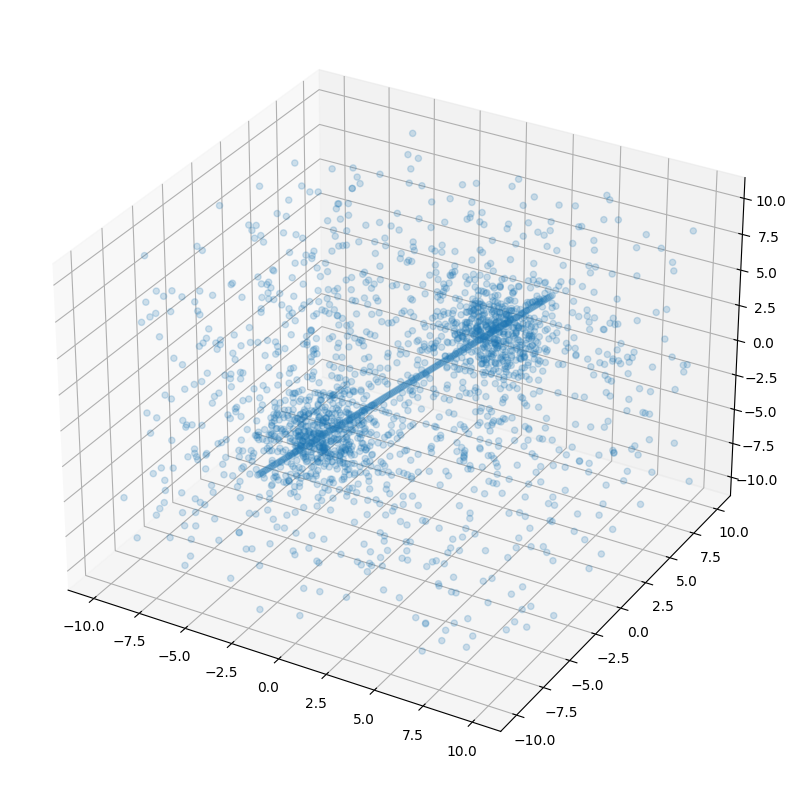

In [243]:
# Visualize data
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(projection='3d')
ax.scatter(xs, ys, zs, alpha=0.2)
plt.show()

In [244]:
def adjust_distances(dist, boxsize):
    if dist > boxsize / 2:
        dist = boxsize - dist
    elif dist <= -boxsize / 2:
        dist = boxsize + dist
    return dist

    

In [245]:
# Periodic boundary conditions (box size 20)
def periodic_distance_matrix(xs, ys, zs, boxsize):
    points = np.vstack((xs, ys, zs)).T
    num_points = points.shape[0]
    dist_matrix = np.zeros((num_points, num_points))
    for i in range(num_points):
        delta = points - points[i]
        delta = delta - boxsize * np.round(delta / boxsize)
        dist_matrix[i] = np.sqrt(np.sum(delta**2, axis=1))
        # dx = delta[:,0]
        # dy = delta[:,1]
        # dz = delta[:,2]

        # new_dx = np.array([adjust_distances(d, boxsize) for d in dx])
        # new_dy = np.array([adjust_distances(d, boxsize) for d in dy])
        # new_dz = np.array([adjust_distances(d, boxsize) for d in dz])
        # dist_matrix[i] = np.sqrt(new_dx**2 + new_dy**2 + new_dz**2)
    return dist_matrix

boxsize = 20
distance_matrix = periodic_distance_matrix(xs, ys, zs, boxsize)

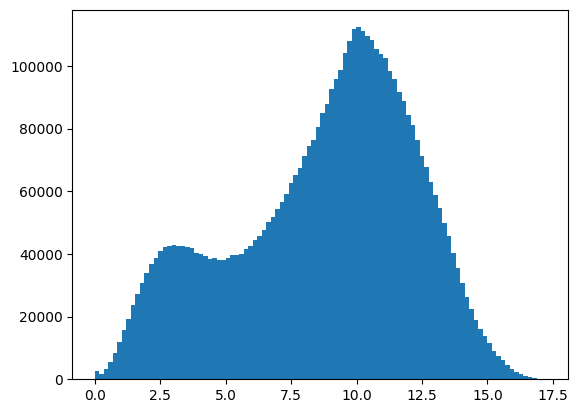

In [246]:
plt.hist(distance_matrix.flatten(), bins=100)
plt.show()

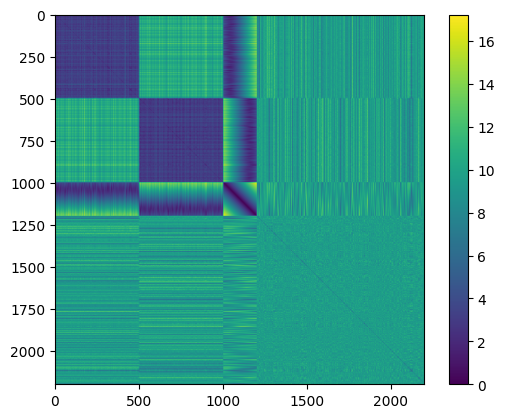

In [247]:
# Visualize distance matrix
plt.imshow(distance_matrix)
plt.colorbar()
plt.show()

In [248]:
# Create a thresholded distance matrix
threshold = 0.5  # Set your desired threshold value

nearest_neighbor_matrix = np.where(distance_matrix < threshold, distance_matrix, 0)

In [249]:
# Build nearest neighbor graph (10 neighbors)
# num_points = len(points)
# num_nn = 10


# nearest_neighbor_matrix = np.zeros_like(distance_matrix)
# for i in range(num_points):
#     nearest_indices = np.argsort(distance_matrix[i])[1:num_nn + 1]
#     nearest_neighbor_matrix[i, nearest_indices] = distance_matrix[i, nearest_indices]

In [250]:
# from scipy.stats import wasserstein_distance
# emd = wasserstein_distance(np.sort(a), np.sort(b))

In [251]:
# from scipy.stats import wasserstein_distance

# num_points = nearest_neighbor_matrix.shape[0]
# wasserstein_matrix = np.zeros((num_points, num_points))

# for i in range(num_points):
#     row_i = np.sort(nearest_neighbor_matrix[i])
#     for j in range(i, num_points):
#         row_j = np.sort(nearest_neighbor_matrix[j])
#         dist = wasserstein_distance(row_i, row_j)
#         wasserstein_matrix[i, j] = dist
#         wasserstein_matrix[j, i] = dist  # symmetric

# plt.imshow(wasserstein_matrix)
# plt.colorbar(label='Wasserstein Distance')
# plt.title('Wasserstein Distance Matrix')
plt.show()

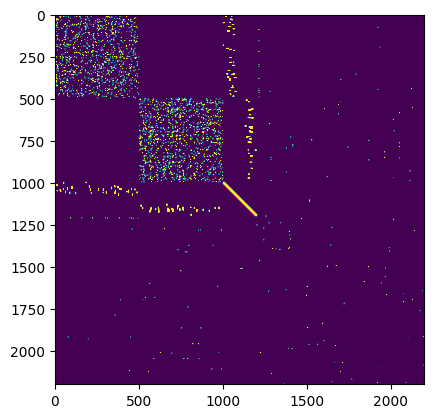

In [252]:
plt.imshow(nearest_neighbor_matrix, vmax=0.01)

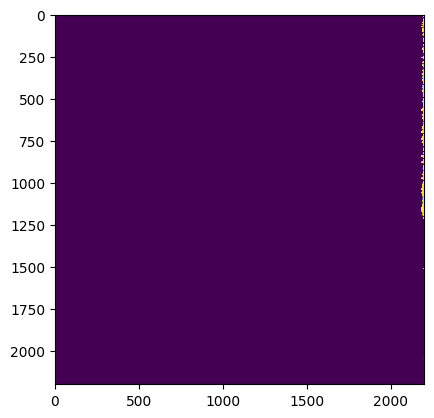

In [253]:
plt.imshow(np.sort(nearest_neighbor_matrix, axis=1), vmax=0.001)

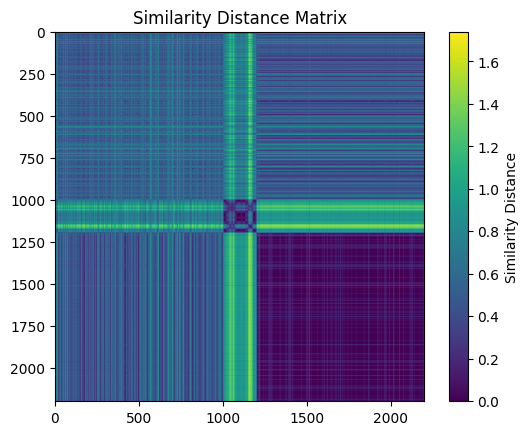

In [254]:
# Calculate similarity distances between each point's row of distances in distance_matrix
# We'll use Euclidean distance between the rows of distance_matrix

similarity_distances = euclidean_distances(np.sort(nearest_neighbor_matrix, axis=1))
plt.imshow(similarity_distances)
plt.colorbar(label='Similarity Distance')
plt.title('Similarity Distance Matrix')
plt.show()

/Users/anasofiauzsoy/anaconda/envs/py310_clone/lib/python3.10/site-packages/matplotlib/cbook/__init__.py:1335: ComplexWarning:

Casting complex values to real discards the imaginary part



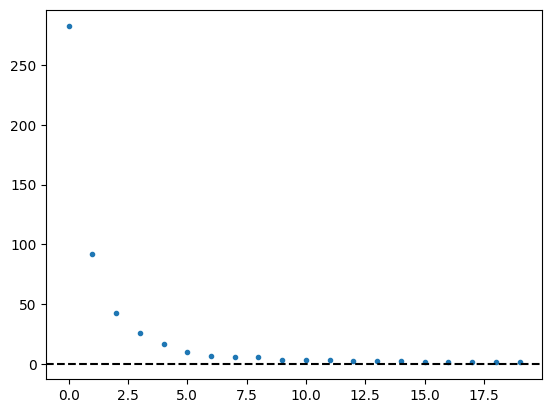

In [255]:
# Isomap embedding
D = similarity_distances
# D = wasserstein_matrix

num_points = D.shape[0]
C = np.eye(num_points) - (1 / num_points)*np.ones_like(D)
B = -0.5 * np.matmul(C, np.matmul(D, C))
evals, evecs = np.linalg.eig(B)

plt.plot(evals[:20], '.')
plt.axhline(0, color='k', linestyle='--')

In [256]:
evals[:30]

array([282.15385621+0.j,  91.73427572+0.j,  42.71010702+0.j,
        25.66928995+0.j,  16.42709213+0.j,  10.33450046+0.j,
         6.53412858+0.j,   5.8951475 +0.j,   5.7986016 +0.j,
         3.65122363+0.j,   3.08265923+0.j,   2.87395587+0.j,
         2.41150487+0.j,   2.08408202+0.j,   2.01294579+0.j,
         1.82202736+0.j,   1.45838406+0.j,   1.37785455+0.j,
         1.20478997+0.j,   1.17965568+0.j,   0.94758014+0.j,
         0.92152596+0.j,   0.8915126 +0.j,   0.87682694+0.j,
         0.8247458 +0.j,   0.79522469+0.j,   0.6755681 +0.j,
         0.64666336+0.j,   0.59240141+0.j,   0.56546282+0.j])

In [257]:
# Use only leading positive eigenvalues
num_positive = np.minimum(np.where(evals < 0)[0][0] - 1, 10)
# num_positive = 10

print(np.sum(num_positive))
num_to_keep = max(2, np.sum(num_positive))
print(f"Keeping {num_to_keep} dimensions")
X = evecs[:, :num_to_keep] * np.sqrt(evals[:num_to_keep])

10
Keeping 10 dimensions


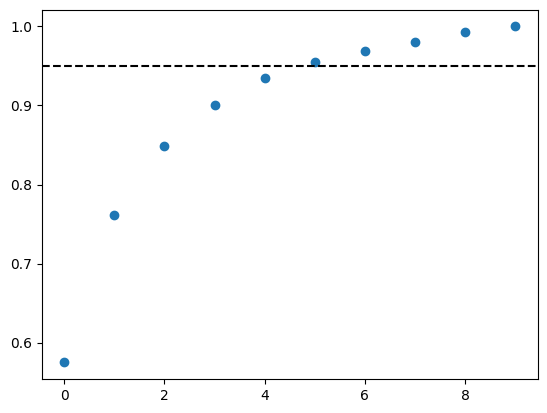

In [258]:
plt.plot(np.cumsum(evals[:num_to_keep] / np.sum(evals[:num_to_keep])), 'o')
plt.axhline(0.95, color='k', linestyle='--')

/Users/anasofiauzsoy/anaconda/envs/py310_clone/lib/python3.10/site-packages/matplotlib/axes/_axes.py:4411: ComplexWarning:

Casting complex values to real discards the imaginary part



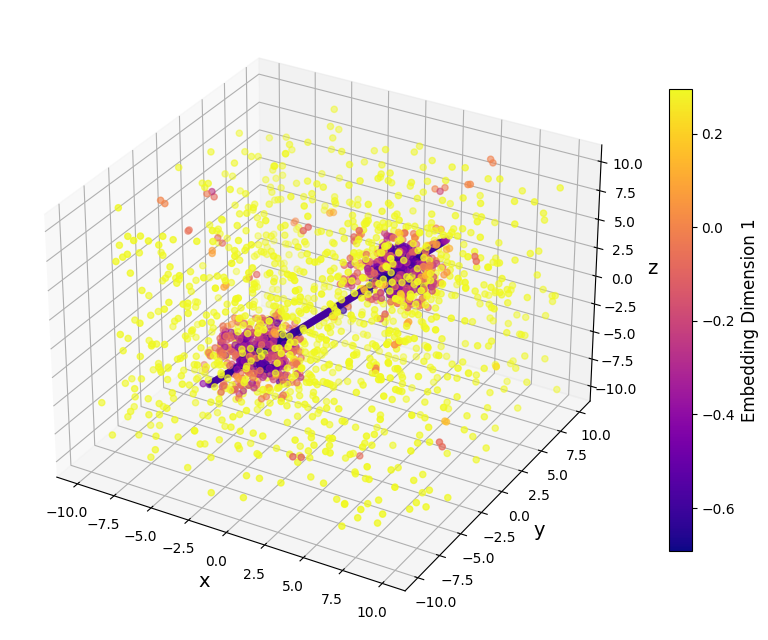

In [259]:
# PCA on Isomap embedding
# pca = PCA(n_components=3)
# embedding = pca.fit_transform(np.real(X))
# # pca.fit(np.real(X.T))

# print("Explained variance ratio:", pca.explained_variance_ratio_)
embedding = X[:, :3]  # Use the first 3 dimensions for visualization

# Visualize embedding
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(projection='3d')
p = ax.scatter(xs, ys, zs, c=embedding[:,0], cmap='plasma')
# p = ax.scatter(xs, ys, zs, c=pca.components_[0])
ax.set_xlabel('x', fontsize=14)
ax.set_ylabel('y', fontsize=14)
ax.set_zlabel('z', fontsize=14)
cbar = fig.colorbar(p, ax=ax, shrink=0.6)
cbar.set_label("Embedding Dimension 1", fontsize=12)
plt.show()

In [260]:
# fig.savefig('simulation_embedding.pdf', bbox_inches='tight')

In [261]:
embedding[:,0]

array([-0.23197165+0.j, -0.08050527+0.j, -0.2447718 +0.j, ...,
        0.14931331+0.j,  0.29515798+0.j,  0.29515798+0.j])

In [262]:
# Interactive plot
import plotly.express as px
fig = px.scatter_3d(x=xs, y=ys, z=zs, color = np.real(embedding[:,0]))
fig.update_layout(margin=dict(l=0, r=0, b=0, t=0))
fig.show()

/Users/anasofiauzsoy/anaconda/envs/py310_clone/lib/python3.10/site-packages/numpy/lib/histograms.py:839: ComplexWarning:

Casting complex values to real discards the imaginary part

/Users/anasofiauzsoy/anaconda/envs/py310_clone/lib/python3.10/site-packages/matplotlib/axes/_axes.py:6793: ComplexWarning:

Casting complex values to real discards the imaginary part



(array([ 223.,  164.,   79.,   93.,  115.,   65.,  201.,   58.,   32.,
        1170.]),
 array([-0.69153905, -0.59286934, -0.49419964, -0.39552994, -0.29686024,
        -0.19819053, -0.09952083, -0.00085113,  0.09781857,  0.19648828,
         0.29515798]),
 <BarContainer object of 10 artists>)

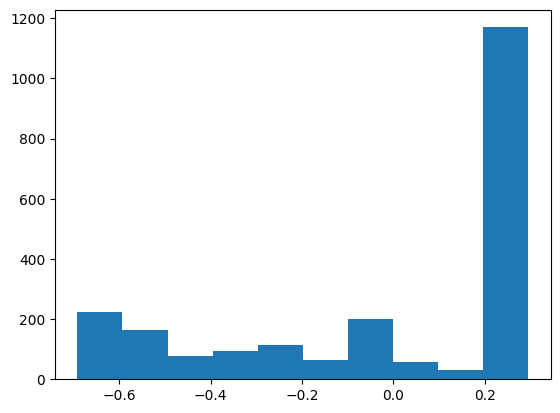

In [263]:
plt.hist(embedding[:,0], bins=10)

/Users/anasofiauzsoy/anaconda/envs/py310_clone/lib/python3.10/site-packages/matplotlib/cbook/__init__.py:1335: ComplexWarning:

Casting complex values to real discards the imaginary part



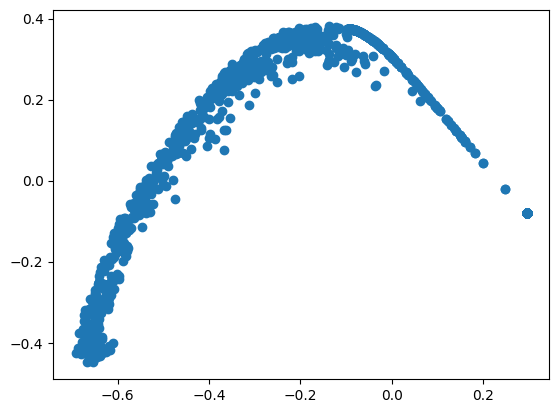

In [264]:
plt.plot(embedding[:,0], embedding[:,1], 'o')
# plt.xlabel("PCA 1")
# plt.ylabel("PCA 2")

In [265]:
len(blob1), len(blob2), len(line), len(rand_points)

(500, 500, 200, 1000)

In [266]:
1000 + 200 + 500 + 500

2200

In [267]:
points.shape

(2200, 3)

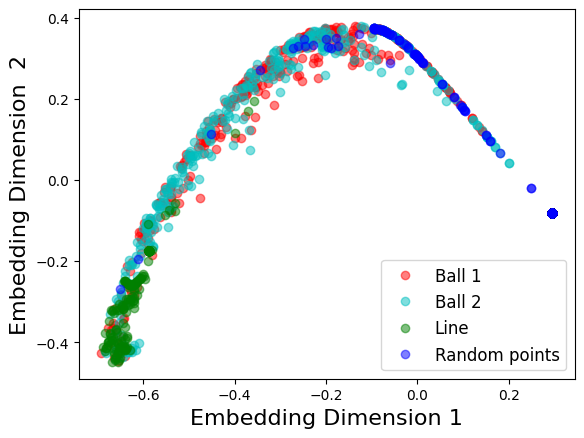

In [268]:
plt.plot(embedding[:len(blob1),0], embedding[:len(blob1),1], 'o', color='r', alpha=0.5, label="Ball 1")
plt.plot(embedding[len(blob1):(len(blob1) + len(blob2)),0], 
         embedding[len(blob1):(len(blob1) + len(blob2)),1], 'o', color='c', alpha=0.5, label="Ball 2")
plt.plot(embedding[(len(blob1) + len(blob2)):(len(blob1) + len(blob2) + len(line)),0], 
         embedding[(len(blob1) + len(blob2)):(len(blob1) + len(blob2) + len(line)),1], 'o', color='g', alpha=0.5, label="Line")
plt.plot(embedding[(len(blob1) + len(blob2) + len(line)):len(points),0],
        embedding[(len(blob1) + len(blob2) + len(line)):len(points),1], 'o', color='b', alpha=0.5, label="Random points")
plt.xlabel("Embedding Dimension 1", fontsize=16)
plt.ylabel("Embedding Dimension  2", fontsize=16)
plt.legend(fontsize=12)
plt.show()

In [278]:
embedding.shape, len(points), len(rand_points)

((2200, 3), 2200, 1000)

/Users/anasofiauzsoy/anaconda/envs/py310_clone/lib/python3.10/site-packages/matplotlib/axes/_axes.py:4411: ComplexWarning:

Casting complex values to real discards the imaginary part

/var/folders/0r/_1bnthz146q2xj0c42f4nl_80000gq/T/ipykernel_33811/1051801110.py:22: MatplotlibDeprecationWarning:

The draw_all function was deprecated in Matplotlib 3.6 and will be removed two minor releases later. Use fig.draw_without_rendering() instead.

/Users/anasofiauzsoy/anaconda/envs/py310_clone/lib/python3.10/site-packages/matplotlib/cbook/__init__.py:1335: ComplexWarning:

Casting complex values to real discards the imaginary part

/var/folders/0r/_1bnthz146q2xj0c42f4nl_80000gq/T/ipykernel_33811/1051801110.py:43: MatplotlibDeprecationWarning:

The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.



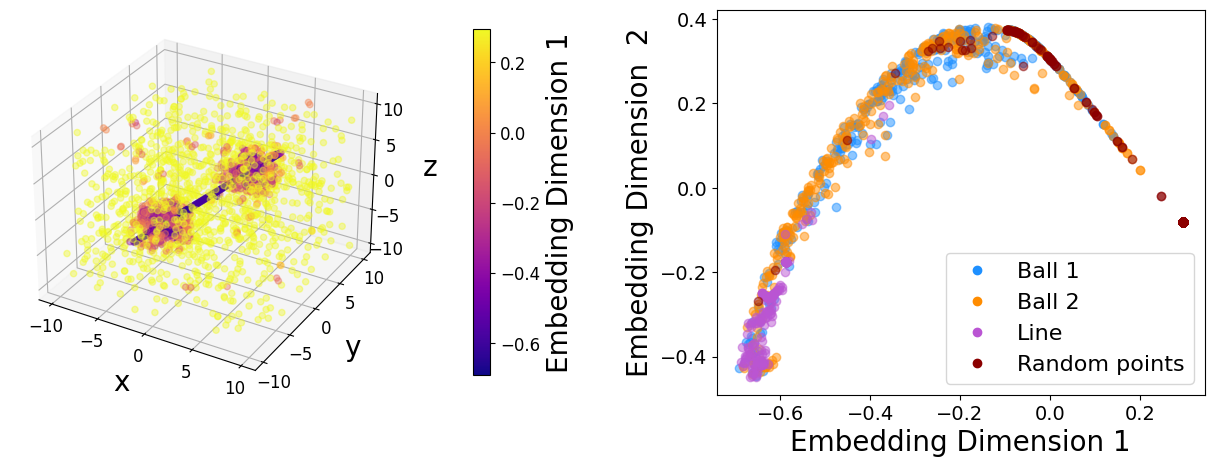

In [296]:
# fig = plt.figure(figsize=(18,5))
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18,5),
                             width_ratios=[8,5])
axes[0].remove() 

ax = fig.add_subplot(1, 2, 1, projection='3d')
ax = plt.subplot(121, projection='3d')

p = ax.scatter(xs, ys, zs, c=embedding[:,0], cmap='plasma', alpha=0.4)
# p = ax.scatter(xs, ys, zs, c=pca.components_[0])
ax.set_xlabel('x', fontsize=20)
ax.set_ylabel('y', fontsize=20)
ax.set_zlabel('z', fontsize=20)
ax.set_xticks([-10, -5, 0, 5, 10])
ax.set_yticks([-10, -5, 0, 5, 10])
ax.set_zticks([-10, -5, 0, 5, 10])
ax.tick_params(axis='both', which='major', labelsize=12, pad = -1)
ax.tick_params(axis='both', which='minor', labelsize=12, pad = -1)

cbar = fig.colorbar(p, ax=ax, shrink=0.9, aspect=20, pad=0.1)
cbar.set_alpha(1)
cbar.draw_all()
cbar.set_label("Embedding Dimension 1", fontsize=20)
cbar.ax.tick_params(labelsize=12)
ax1 = axes[1]
ax1.plot(embedding[:len(blob1),0], embedding[:len(blob1),1], 'o',
          color='dodgerblue', alpha=0.5, label="Ball 1")
ax1.plot(embedding[len(blob1):(len(blob1) + len(blob2)),0], 
         embedding[len(blob1):(len(blob1) + len(blob2)),1], 'o', 
         color='darkorange', alpha=0.5, label="Ball 2")
ax1.plot(embedding[(len(blob1) + len(blob2)):(len(blob1) + len(blob2) + len(line)),0], 
         embedding[(len(blob1) + len(blob2)):(len(blob1) + len(blob2) + len(line)),1], 
         'o', color='mediumorchid', alpha=0.5, label="Line")
ax1.plot(embedding[-len(rand_points):,0],
        embedding[-len(rand_points):,1], 'o', 
        color='darkred', alpha=0.5, label="Random points")
ax1.set_xlabel("Embedding Dimension 1", fontsize=20)
ax1.set_ylabel("Embedding Dimension  2", fontsize=20)
ax1.tick_params(axis='both', which='major', labelsize=14)
ax1.tick_params(axis='both', which='minor', labelsize=14)

leg = ax1.legend(fontsize=16)
for lh in leg.legendHandles: 
    lh.set_alpha(1)

plt.tight_layout
plt.show()

In [297]:
fig.savefig('simulation_embedding.pdf', bbox_inches='tight')

/Users/anasofiauzsoy/anaconda/envs/py310_clone/lib/python3.10/site-packages/matplotlib/collections.py:192: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)
/Users/anasofiauzsoy/anaconda/envs/py310_clone/lib/python3.10/site-packages/matplotlib/collections.py:551: ComplexWarning: Casting complex values to real discards the imaginary part
  (np.asanyarray(self.convert_xunits(offsets[:, 0]), float),
/Users/anasofiauzsoy/anaconda/envs/py310_clone/lib/python3.10/site-packages/matplotlib/collections.py:552: ComplexWarning: Casting complex values to real discards the imaginary part
  np.asanyarray(self.convert_yunits(offsets[:, 1]), float)))
/Users/anasofiauzsoy/anaconda/envs/py310_clone/lib/python3.10/site-packages/matplotlib/colors.py:389: ComplexWarning: Casting complex values to real discards the imaginary part
  c = tuple(map(float, c))


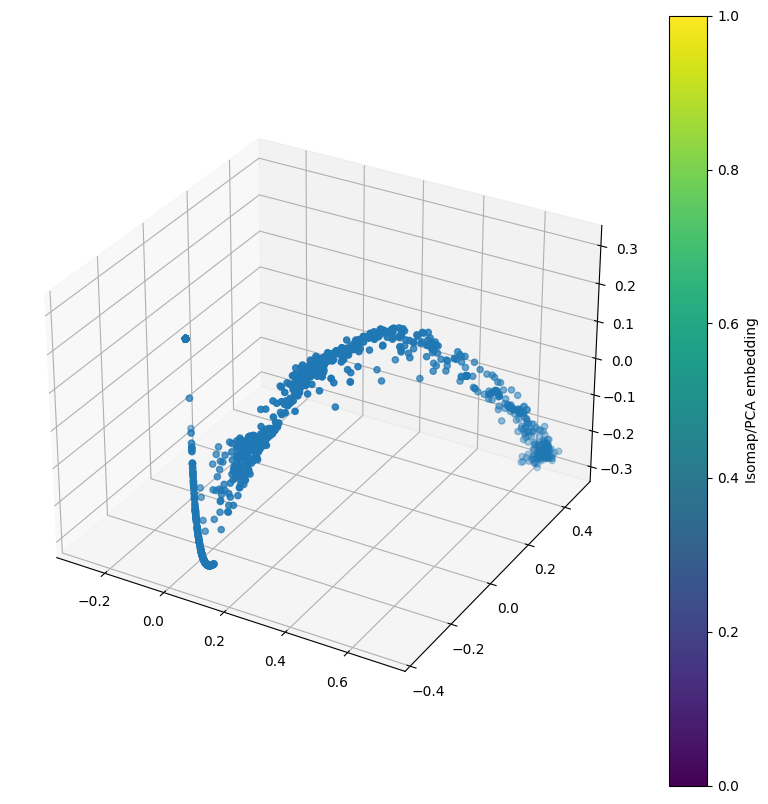

In [121]:
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(projection='3d')
p = ax.scatter(embedding[:,0], embedding[:,1], embedding[:,2])
# p = ax.scatter(xs, ys, zs, c=pca.components_[0])

cbar = fig.colorbar(p, ax=ax)
cbar.set_label("Isomap/PCA embedding")
plt.show()

In [122]:
blob1 = z.rvs(500)
blob2 = z2.rvs(500)
line = np.array([[-5 + 0.05 * j]*3 for j in range(200)])
rand_points = np.random.uniform(-10, 9, (1000, 3))

In [123]:
rand_points.shape[0]

1000

In [124]:
import plotly.express as px
fig = px.scatter_3d(
    x=embedding[:,0], 
    y=embedding[:,1], 
    z=embedding[:,2], 
    color=(['Blob 1']*blob1.shape[0] + ['Blob 2']*blob2.shape[0] + ['Line']*line.shape[0] + ['Random']*rand_points.shape[0]),
    color_discrete_map={
        'Blob 1': 'blue',
        'Blob 2': 'red',
        'Line': 'green',
        'Random': 'cyan'
    },
    opacity=0.5,
    labels={'color': 'Group'}
)
fig.update_traces(marker=dict(size=4))
fig.update_layout(margin=dict(l=0, r=0, b=0, t=0))
fig.show()

TypeError: Object of type complex is not JSON serializable

In [ ]:
fig = px.scatter_3d(
    x=embedding[:,0], 
    y=embedding[:,1], 
    z=embedding[:,2], 
    color=np.sum(nearest_neighbor_matrix, axis=1),
    opacity=0.5,
)
fig.update_traces(marker=dict(size=4))
fig.update_layout(margin=dict(l=0, r=0, b=0, t=0))
fig.show()

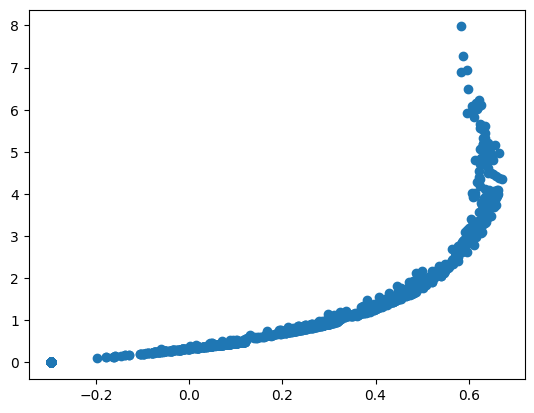

In [341]:
plt.plot(embedding[:,0], np.sum(nearest_neighbor_matrix, axis=1), 'o')

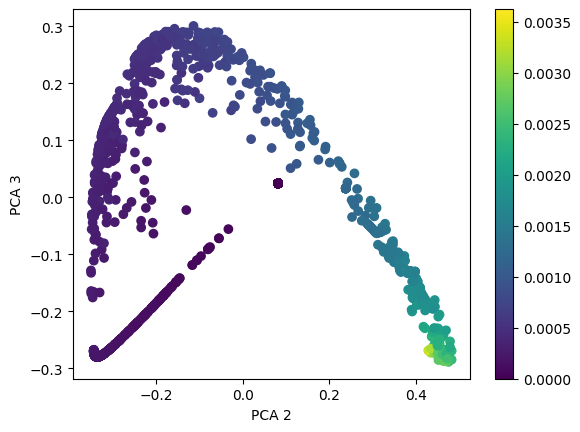

In [291]:
plt.scatter(embedding[:,1], embedding[:,2], c= np.average(nearest_neighbor_matrix, axis=1), cmap='viridis')
plt.xlabel("PCA 2")
plt.ylabel("PCA 3")
plt.colorbar()

In [253]:
points

array([[-2.88572658, -5.96892267, -3.63998901],
       [-4.66088813, -3.48888726, -5.50509352],
       [-1.77184378, -0.99779714, -1.99539457],
       ...,
       [ 8.78412675, -6.16953329, -3.93573692],
       [-9.90755093,  6.80383452, -2.8965216 ],
       [-2.18393313,  2.65782003, -3.85445986]])

ValueError: 'c' argument has 3200 elements, which is inconsistent with 'x' and 'y' with size 2200.

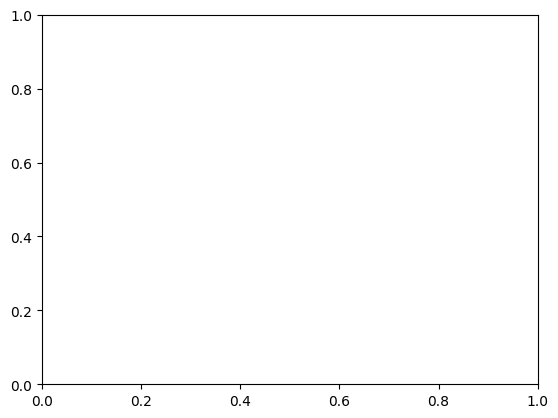

In [254]:
plt.scatter(embedding[:,0], embedding[:,1], c = points[:,0])
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")